Чтобы искать по текстам, нам надо эти тексты получить. Я предлагаю для этого использовать текст страниц. Так как это интересно.


Чтобы получить данные со стараницы нам надо сделать 2 вещи:


*   Сделать запрос к странице, чтобы получить HTML содержание страницы
*   Получить из HTML данные


**Чтобы получить html нам надо выполнить HTTP запрос. Но что это?**


Когда вы вводите адрес в браузер, происходит не магия, а четкий диалог по протоколу HTTP. Это правила, по которым клиент (ваш компьютер) общается с сервером (сайтом).

HTTP работает по принципу "запрос-ответ". Вы отправляете запрос (аналог: "Принеси мне страницу по адресу X"), а сервер возвращает ответ — HTML-код, картинку или данные.

Каждый запрос содержит метод (обычно GET — «дай содержимое»), адрес (URL) и заголовки (дополнительная инфо: браузер, язык). Сервер отвечает:
- Кодом статус: 200 (всё ок), 404 (не найдено), 500 (ошибка сервера)
- Самим содержимым.


*Показать, как работает HTTP в браузере*

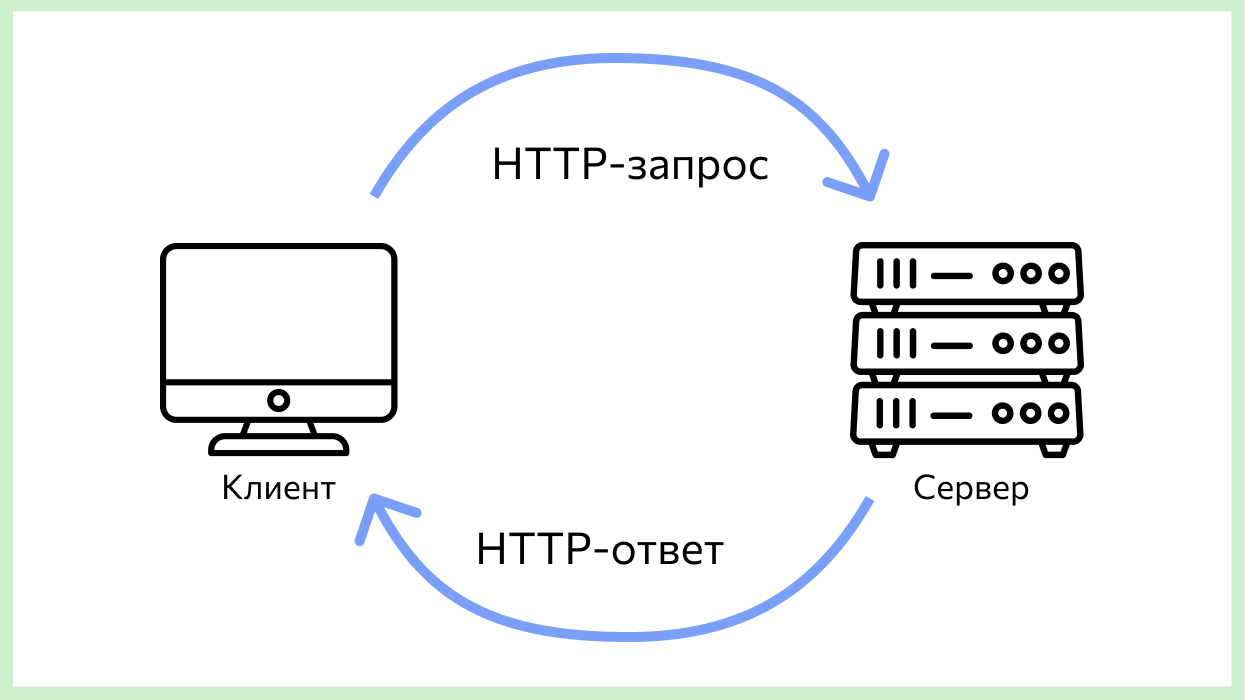

**Как выполнить HTTP в python**

In [ ]:
import requests

url = "https://korol-i-shut.su/songs/text/smelchak-i-veter.html"
# Выполняем get-запрос
response = requests.get(url)
print(response.status_code)
print(response.content)

200
b'<!doctype html>\n<html lang="ru" class="h-100" data-bs-theme="dark">\n<head>\n    <title>\xd0\xa2\xd0\xb5\xd0\xba\xd1\x81\xd1\x82 \xd0\xbf\xd0\xb5\xd1\x81\xd0\xbd\xd0\xb8 \xd0\xa1\xd0\xbc\xd0\xb5\xd0\xbb\xd1\x8c\xd1\x87\xd0\xb0\xd0\xba \xd0\xb8 \xd0\x92\xd0\xb5\xd1\x82\xd0\xb5\xd1\x80 | \xd0\xb0\xd0\xbb\xd1\x8c\xd0\xb1\xd0\xbe\xd0\xbc \xd0\x9a\xd0\xb0\xd0\xbc\xd0\xbd\xd0\xb5\xd0\xbc \xd0\xbf\xd0\xbe \xd0\x93\xd0\xbe\xd0\xbb\xd0\xbe\xd0\xb2\xd0\xb5 | \xd0\xb0\xd0\xbb\xd1\x8c\xd0\xb1\xd0\xbe\xd0\xbc \xd0\xa1\xd0\xbe\xd0\xb1\xd1\x80\xd0\xb0\xd0\xbd\xd0\xb8\xd0\xb5 | \xd0\xb3\xd1\x80\xd1\x83\xd0\xbf\xd0\xbf\xd0\xb0 \xd0\x9a\xd0\xbe\xd1\x80\xd0\xbe\xd0\xbb\xd1\x8c \xd0\xb8 \xd0\xa8\xd1\x83\xd1\x82</title>\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\n    <meta name="viewport" content="width=device-width, initial-scale=1">\n    <link href=\'https://fonts.googleapis.com/css?family=Rubik:400,500,700&subset=latin,cyrillic\' rel=\'stylesheet\' type=\'text/css\'>\n    <link hr

Видим, что нам вернулась в content странная строка. Что это?

**Что такое HTML?**


Это язык верстки страниц. Благодаря ему браузер понимает, как отобразить страницу. HTML содержит теги и текст страницы. Теги существуют для браузера, чтобы он правильно отобразить содержание страницы.


Рассмотрем на примере:

```html
<!DOCTYPE html>
<html>
  <head>
    <title>My Page Title</title>
  </head>
  <body>
    <h1>Welcome Students</h1>
    <p>This is a <strong>nested</strong> example.</p>
  </body>
</html>
```

html - это всегда древовидная структура. Представленный выше файл можно представить в виде:
```
html
├── head
│   └── title
│       └── "My Page Title"
└── body
    ├── h1
    │   └── "Welcome Students"
    └── p
        ├── "This is a "
        ├── strong
        │   └── "nested"
        └── " example."
```


HTML мы получили, но как нам в нем что-то найти?

Для этого воспользуемся библиотекой BeatufulSoup

In [ ]:
from bs4 import BeautifulSoup

# Создаем объект BeautifulSoup
bs = BeautifulSoup(response.content, "html.parser")
# Найти первый тег header
bs.select_one("header")

<header class="header">
<a class="header__logo" href="/">
            группа Король и Шут        </a>
<nav class="header__menu">
<a href="https://korol-i-shut.su/albums/">Альбомы Король и Шут</a>
<a href="https://korol-i-shut.su/knyazz/albums/">Альбомы Княzz</a>
<a href="/serial/">Сериал о группе</a>
</nav>
</header>

In [ ]:
# Найти первый тег header в body
print(bs.select_one("header a"))

<a class="header__logo" href="/">
            группа Король и Шут        </a>


In [ ]:
# Получим текст
print(bs.select_one("header").text)



            группа Король и Шут        

Альбомы Король и Шут
Альбомы Княzz
Сериал о группе




In [ ]:
# Получим текст
print(bs.select_one("article").text)

Припев:Я ведь не из робких,Все мне по плечу.Сильный я и ловкий,Ветра проучу!Дул сильный ветер, крыши рвал.И, несмотря на поздний час,В округе вряд ли кто-то спал -Стихия не на шутку разошлась.Но вдруг какой-то парень с криком побежалИ принялся махать метлой:"Ах, ветер, негодяй, ты спать мне помешал,А ну-ка выходи на бой!"(Припев)И ветер закружился, заметалсяИ ели начал с корнем рвать:"Откуда этот сумасшедший взялся,Что хочет с ветром воевать".Но парень не сдавался и метлой махал,И удалялся вглубь полей.И впрямь неплохо с ветром воевал,А ветер становился злей...(Припев)Но вдруг метла со свистом улетела прочьИ храбрый парень вслед за ней.А после этого спокойней стала ночь -Исчез во мраке дуралей.Его под утро пастухи нашли в стогу -Он очень крепко спал,А ветер песни напевал емуИ кудри ласково трепал.(Припев)  


*Показать, как получить selector в браузуере*

In [ ]:
# Получим текст
print(
    bs.select_one(
        "html.h-100 body.page main.page-main div.container div.content article"
    ).get_text(separator="\n")
)

Припев:
Я ведь не из робких,
Все мне по плечу.
Сильный я и ловкий,
Ветра проучу!
Дул сильный ветер, крыши рвал.
И, несмотря на поздний час,
В округе вряд ли кто-то спал -
Стихия не на шутку разошлась.
Но вдруг какой-то парень с криком побежал
И принялся махать метлой:
"Ах, ветер, негодяй, ты спать мне помешал,
А ну-ка выходи на бой!"
(Припев)
И ветер закружился, заметался
И ели начал с корнем рвать:
"Откуда этот сумасшедший взялся,
Что хочет с ветром воевать".
Но парень не сдавался и метлой махал,
И удалялся вглубь полей.
И впрямь неплохо с ветром воевал,
А ветер становился злей...
(Припев)
Но вдруг метла со свистом улетела прочь
И храбрый парень вслед за ней.
А после этого спокойней стала ночь -
Исчез во мраке дуралей.
Его под утро пастухи нашли в стогу -
Он очень крепко спал,
А ветер песни напевал ему
И кудри ласково трепал.
(Припев)  


Соберем в функцию

In [ ]:
def get_song_text(url):
    response = requests.get(url)

    if response.status_code == 200:
        soup = BeautifulSoup(response.content, "html.parser")

        content_div = soup.select_one(
            "html.h-100 body.page main.page-main div.container div.content"
        )

        if content_div:
            return content_div.get_text(separator="\n")
        else:
            raise ValueError(f"Не найден текст на странице {url}")
    else:
        raise IOError(f"Ошибка выполнения запроса: {response.status_code} {url}")

In [ ]:
get_song_text("https://korol-i-shut.su/songs/text/smelchak-i-veter.html")

'\n\nПрипев:\nЯ ведь не из робких,\nВсе мне по плечу.\nСильный я и ловкий,\nВетра проучу!\nДул сильный ветер, крыши рвал.\nИ, несмотря на поздний час,\nВ округе вряд ли кто-то спал -\nСтихия не на шутку разошлась.\nНо вдруг какой-то парень с криком побежал\nИ принялся махать метлой:\n"Ах, ветер, негодяй, ты спать мне помешал,\nА ну-ка выходи на бой!"\n(Припев)\nИ ветер закружился, заметался\nИ ели начал с корнем рвать:\n"Откуда этот сумасшедший взялся,\nЧто хочет с ветром воевать".\nНо парень не сдавался и метлой махал,\nИ удалялся вглубь полей.\nИ впрямь неплохо с ветром воевал,\nА ветер становился злей...\n(Припев)\nНо вдруг метла со свистом улетела прочь\nИ храбрый парень вслед за ней.\nА после этого спокойней стала ночь -\nИсчез во мраке дуралей.\nЕго под утро пастухи нашли в стогу -\nОн очень крепко спал,\nА ветер песни напевал ему\nИ кудри ласково трепал.\n(Припев)  \n\n\n\n\n\n\n\n'

## Важно

Не все страницы можно получить при помощи requests. Часть страниц строится в момент открытия, поэтому request выдаст не то, что вы ожидаете.

Если на странице беллебирда, просто используйте другую страницу

In [ ]:
# Например, youtube не получится парсить
response = requests.get("https://www.youtube.com/watch?v=dQw4w9WgXcQ")
print(response.status_code)
bs = BeautifulSoup(response.content, "html.parser")
print(bs.select_one("h1"))

200
None


## Домашнее задание

1. Посмотрите, как происходит http-запрос в браузере
2. Напишите свою простую html-страницу при помощи LLM(DeepSeek, ChatGPT). Попробуйте отредактировать её, добавить жирный текст, заголовки, абзацы
3. Напишите функцию, которая парсит текст со старницы. Дальше мы будем делать текстовый поиск по этим данным